In [1]:
!nvidia-smi


/bin/bash: line 1: nvidia-smi: command not found


## Machine Learning Pipeline :

### Phase 0 : Import libraries: 

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy as sp

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split as tts


import shutil
from google.colab import drive


print("done!")

done!


### Phase 1 : Import Data :


In [3]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
path_from_drive = "/content/drive/MyDrive/simplon_projects/intro_to_ML_project/Clean_Dataset.csv"
df = pd.read_csv(path_from_drive)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [5]:
#df = pd.read_csv("Clean_Dataset.csv")
#df.shape

### Phase 2 : EDA 

#### 1. Naming the column "Unamed:0" as the Index ID

In [6]:
df = df.rename(columns = {df.columns[0]: "id"})

#### 2. displaying as lists the unique elements of each column


In [7]:
airlines = df["airline"].unique().tolist()
flights = df["flight"].unique().tolist()
source_cities = df["source_city"].unique().tolist()
departure_times = df["departure_time"].unique().tolist()
stops = df["stops"].unique().tolist()
arrival_times = df["arrival_time"].unique().tolist()
destination_cities = df["destination_city"].unique().tolist()
classes = df["class"].unique().tolist()

print(f"Airlines: {airlines}\n")
print(f"Number of unique flights: {len(flights)}\n")
print(f"Source Cities: {source_cities}\n")
print(f"Departure Times: {departure_times}\n")
print(f"Stops: {stops}\n")
print(f"Arrival Times: {arrival_times}\n")
print(f"Destination Cities: {destination_cities}\n")
print(f"Classes : {classes}\n")

Airlines: ['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo', 'Air_India']

Number of unique flights: 1561

Source Cities: ['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai']

Departure Times: ['Evening', 'Early_Morning', 'Morning', 'Afternoon', 'Night', 'Late_Night']

Stops: ['zero', 'one', 'two_or_more']

Arrival Times: ['Night', 'Morning', 'Early_Morning', 'Afternoon', 'Evening', 'Late_Night']

Destination Cities: ['Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai', 'Delhi']

Classes : ['Economy', 'Business']



#### 3. Classify the discrete, continuous, and categorical variables

In [8]:
discrete_variables = []
continuous_variables = []
categorical_variables = []


for var in df.columns :
    if df[var].dtype == 'object' :
        categorical_variables.append(var)

    elif df[var].dtype == 'int64' or (df[var].dtype == 'float64' and (df[var].dropna() % 1 == 0).all()) :
        
        if len(df[var].unique()) > 100 :
            continuous_variables.append(var)
        else :
            discrete_variables.append(var)
            
    elif (df[var].dtype == 'float64' and (df[var].dropna() % 1 != 0).any()):
        continuous_variables.append(var)
        
    else:
        print(var, "is unknown")

print("Discrete:", discrete_variables)
print("Continuous:", continuous_variables)
print("Categorical:", categorical_variables)

Discrete: ['days_left']
Continuous: ['id', 'duration', 'price']
Categorical: ['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']


#### 4. Statistical Test :

In [9]:
# Filter to include only the economy class (the common class among all airlines)
df_economy = df[df["class"]== "Economy"]

#list of all unique airlines in the dataset with economy class
airlines = df_economy["airline"].unique().tolist()

##### 4.1. ANOVA test: examine the relationship between airline (economy class) and price: 

In [10]:
# H0 (Null hypothesis): There is no significant relationship between the airline company and price
# H1 (Alternative hypothesis): There is a significant relationship between the airline company and price

dict_airline_prices = {}

# Iterate over each airline, extracting economy class prices
for airline in airlines :
    airline_prices = df_economy[df_economy['airline'] == airline]['price']
    dict_airline_prices[airline] = airline_prices

# Anova test
anova_results = sp.stats.f_oneway(*dict_airline_prices.values())
print(f"P-value:{anova_results[1]}")
alpha = 0.02

if anova_results[1] < alpha:
    print(f"H0 is rejected, which indicates that there is a significant relationship between the airline company and price.")
else:
    print(f"Failed to reject H0, which indicates that there is no significant relationship between the airline company and price.")

P-value:0.0
H0 is rejected, which indicates that there is a significant relationship between the airline company and price.


##### Visualization:

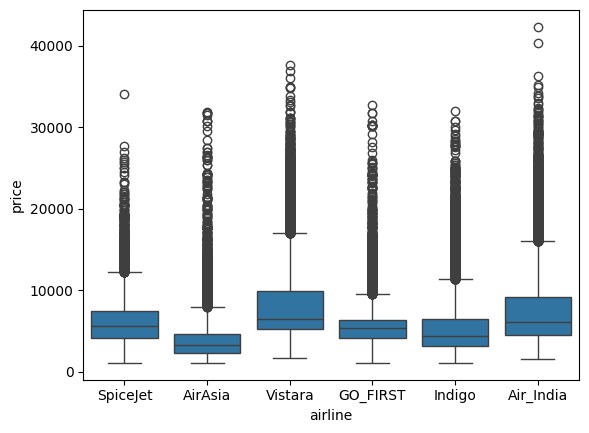

In [11]:
sns.boxplot( data = df_economy, x= "airline",y = "price")
plt.show()

#### 4.2. Pearson correlation test: examine the linear relationship between flight duration and price

In [12]:
results_pearson = sp.stats.pearsonr(df_economy["duration"], df_economy["price"])
print(f"p value : {results_pearson[1]}")
print(f"r : {results_pearson[0]}")

alpha = 0.02

if results_pearson[1] < alpha:
    print(f"H0 is rejected, which indicates that there is a significant relationship between duration and price.")
else:
    print(f"Failed to reject H0, which indicates that there is no significant relationship between duration and price.")

p value : 0.0
r : 0.28837905095900523
H0 is rejected, which indicates that there is a significant relationship between duration and price.


##### Visualization:

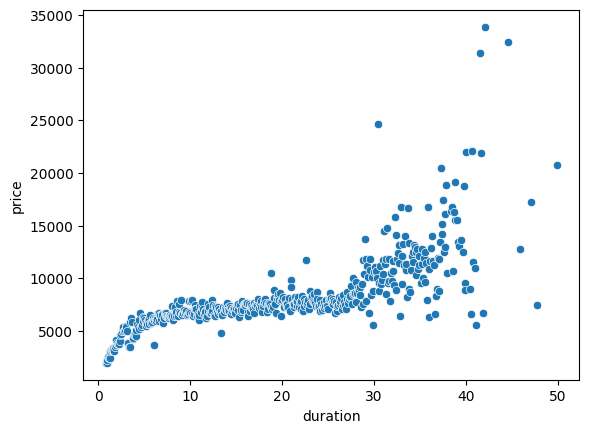

In [13]:
data = df_economy[["duration", "price"]].groupby("duration").mean()
sns.scatterplot( data = data, x= "duration",y = "price")
plt.show()

## Phase 3 : Pre-Processing 

### 1. Encoding ordinal Varibales :

#### 1.1. Exploration

In [14]:
df["departure_time"].unique().tolist()

['Evening', 'Early_Morning', 'Morning', 'Afternoon', 'Night', 'Late_Night']

In [15]:
df["arrival_time"].unique().tolist()

['Night', 'Morning', 'Early_Morning', 'Afternoon', 'Evening', 'Late_Night']

In [16]:
df["stops"].unique().tolist()

['zero', 'one', 'two_or_more']

#### 1.2. Ordinal encoding using Mapping :

In [17]:
# Mapping the stops column to numerical representative values
if df['stops'].dtype == 'object': 
    df['stops'] =df['stops'].map({'zero':0, 'one' : 1, 'two_or_more' :2})
    print("results : ",df['stops'].unique().tolist())
else :
    print("stops column already mapped :",df['stops'].unique().tolist())

results :  [0, 1, 2]


In [18]:
time_mapping = {
    'Early_Morning': 1,
    'Morning': 2,
    'Afternoon': 3,
    'Evening': 4,
    'Night': 5,
    'Late_Night': 6
}
#mapping :
for col in ['arrival_time', 'departure_time' ]:
    if col in df.columns:
        if df[col].dtype == 'object': 
            df[col + '_mapped'] = df[col].map(time_mapping)
            print("results : ",df[col + '_mapped'].unique().tolist())
            df.drop(columns= col , inplace=True)
        else :
            print(f"{col} column already mapped : {df[col+'_mapped'].unique().tolist()}")     
    else :
        print(f"{col} column already mapped : {df[col+'_mapped'].unique().tolist()}")

results :  [5, 2, 1, 3, 4, 6]
results :  [4, 1, 2, 3, 5, 6]


#### 2. Encoding of Nominal Variables Using OneHotMapping : 

#### 2.1. Exploration and preparation :

In [19]:
# Drop the 'flight' column before nominal encoding:
# It has 1,561 unique values — too many for One-Hot Encoding (causes overfitting and memory issues).
# Its useful information is already captured by 'airline', 'source_city', and 'destination_city'.

df.drop(columns="flight", inplace=True)
print("done!")

# drop the "id" column bcs it has no added value in our prediction :
df.drop(columns='id', inplace = True)

done!


In [20]:
# Extract the list of nominal left variables from the df :
columns = df.select_dtypes( include ='object').columns.tolist()

# loop encoding on the list of nominal variables :
for col in columns :
    if col in df.columns :
        if df[col].dtype == 'object':
            encoder = OneHotEncoder(sparse_output=False)
            encoded = encoder.fit_transform(df[[col]])
            df[encoder.get_feature_names_out([col])] = encoded 
            df.drop(columns=col, inplace = True)
        else :
            print("columns are already encoded")
    else :
        print("columns are already encoded and originals were droped")


In [21]:
df

,stops,duration,days_left,price,arrival_time_mapped,departure_time_mapped,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,...,source_city_Kolkata,source_city_Mumbai,destination_city_Bangalore,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Business,class_Economy
0,0,2.17,1,5953,5,4,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,0,2.33,1,5953,2,1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,0,2.17,1,5956,1,1,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,0,2.25,1,5955,3,2,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,0,2.33,1,5955,2,2,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,1,10.08,49,69265,4,2,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
300149,1,10.42,49,77105,5,3,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
300150,1,13.83,49,79099,5,1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
300151,1,10.00,49,81585,4,1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [22]:
df.to_csv('Clean_Dataset_encoded.csv', index=False)
shutil.move('/content/Clean_Dataset_encoded.csv', '/content/drive/MyDrive/simplon_projects/intro_to_ML_project/Clean_Dataset_encoded.csv')
print("Successfully moved to Google Drive!")

Successfully moved to Google Drive!


### Phase 4 : Modeling 

#### 1. Defining the parameters x the features, y the target :

In [23]:
x = df.drop(columns = 'price') #features
y = df['price'] #Target
print("done!")

done!


#### 2. Split the dataset into Test and Train portions :

In [24]:
from sklearn.model_selection import train_test_split as tts
x_train,x_test, y_train, y_test = tts(x 
                                     ,y 
                                     , test_size = 0.2 
                                     , random_state = 42)
print("df has been Splited!")

df has been Splited!


### Phase 5: Training 

####  1. Random Forest Model Training :

In [25]:
from sklearn.ensemble import RandomForestRegressor

RandomForest_model = RandomForestRegressor(n_estimators=100, random_state=42)
RandomForest_model.fit(x_train, y_train)

print('Random Forest Model Has been Trained!')

Random Forest Model Has been Trained!


#### 2. XGBoost Model Training :

In [26]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,       # shrinkage rate
    max_depth=6,             # tree depth
    random_state=42
)

xgb_model.fit(x_train, y_train)

print('XGBoost Model Has been Trained!')

XGBoost Model Has been Trained!


### Phase 6 : Testing 

####  1. Random Forest Model Testing :

In [27]:
y_pred_RF = RandomForest_model.predict(x_test)
print('Random Forest Model Has been Tested!')

Random Forest Model Has been Tested!


####  2. XGBoost Model Testing :

In [28]:
y_pred_xgb = xgb_model.predict(x_test)
print('XGBoost Model Has been Tested!')

XGBoost Model Has been Tested!


### Phase 7 : Evaluation 

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

#### 1. Calculating the metrics R², MAE, RMSE for each Model :

In [ ]:
y_predicted = { 'Random Forest' : y_pred_RF, "XGBoost" : y_pred_xgb}

for model_name, y_pred in y_predicted.items() :
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"Evaluation of model {model_name} ")
    print(f"MAE  (Mean Absolute Error):     {mae:.2f}")
    print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
    print(f"R² Score:                       {r2*100:.4f}%")
    print('='*20 + '\n')

Evaluation of model Random Fores 
MAE  (Mean Absolute Error):     1083.38
RMSE (Root Mean Squared Error): 2786.25
R² Score:                       98.4940%

Evaluation of model XGBoost 
MAE  (Mean Absolute Error):     2332.46
RMSE (Root Mean Squared Error): 4108.73
R² Score:                       96.7251%



#### 2. Model Performance Comparaison and Visualization: Predicted vs Actual Prices :

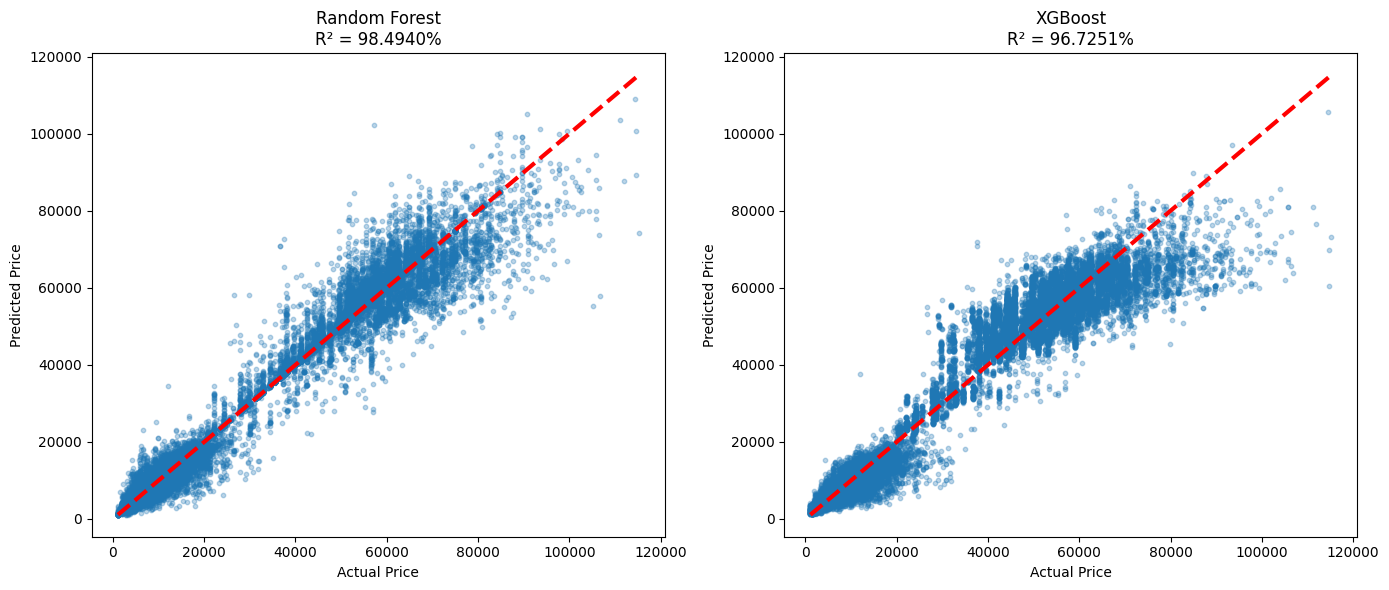

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  

y_predicted = { 'Random Forest' : y_pred_RF, "XGBoost" : y_pred_xgb}

for i, (model_name, y_pred) in enumerate(y_predicted.items()):
    # Calculate metrics for this model
    r2 = r2_score(y_test, y_pred)
    
    axes[i].scatter(y_test, y_pred, alpha=0.3, s=10)
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3)
    axes[i].set_xlabel("Actual Price")
    axes[i].set_ylabel("Predicted Price")
    axes[i].set_title(f"{model_name}\nR² = {r2*100:.4f}%")

plt.tight_layout()  
plt.show()
